In [25]:
#1. Import Libraries
#for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for machine learning models and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

#for model explainability
import shap

#for database connection
from sqlalchemy import create_engine
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [26]:
#2. EDA
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Head: \n", df.head())
print("Checking for null values: \n", df.isnull().sum())

Head: 
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contr

In [27]:
#3. Clean & Encode
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c])

df_clean = df.copy()

In [28]:
#4. Train Test Split
X = df_clean.drop(['customerID','Churn'], axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


In [29]:
#5. Model Training & Selecting Best Model
models = {
    "Logistic": LogisticRegression(max_iter=1500),
    "DecisionTree": DecisionTreeClassifier(max_depth=6),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

results = []
best_auc = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    results.append({
        "model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    })

    if auc > best_auc:
        best_auc = auc
        best_model = model
        best_name = name

results = pd.DataFrame(results)
print(results)
print(f"Best Model: {best_name} with AUC: {best_auc}")

c:\Users\TANVI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


          model  Accuracy  Precision    Recall        F1       AUC
0      Logistic  0.799148   0.640000  0.556150  0.595136  0.840887
1  DecisionTree  0.784244   0.603550  0.545455  0.573034  0.824582
2       XGBoost  0.778566   0.595679  0.516043  0.553009  0.818540
Best Model: Logistic with AUC: 0.8408871321914799


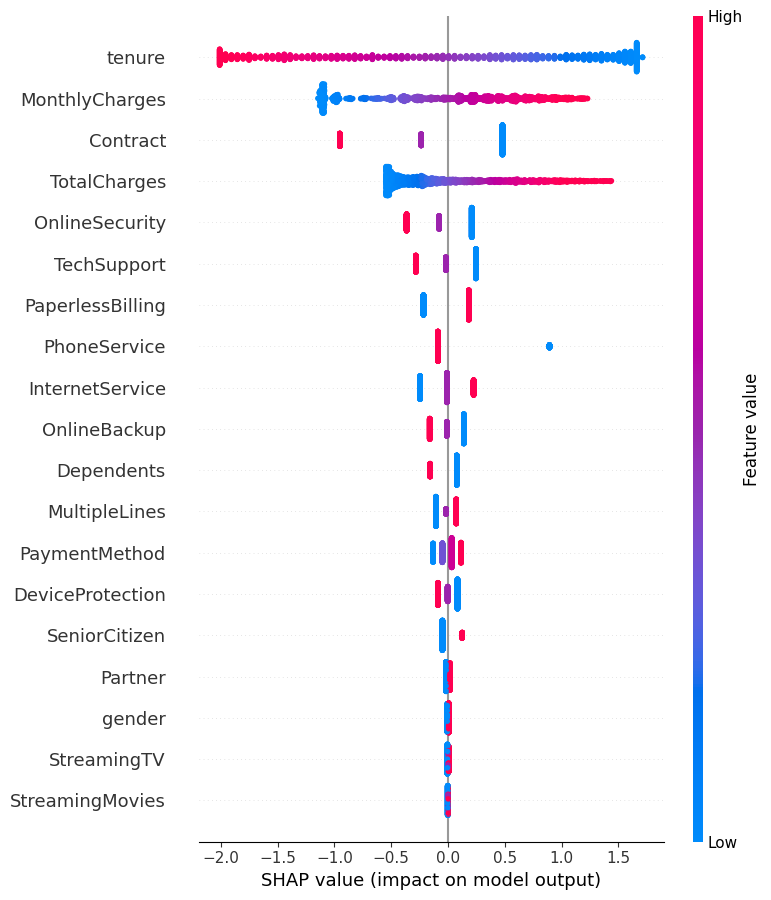

In [ ]:
#6. SHAP Explainability
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


In [31]:
#7. Time Series Creation
monthly_churn = df_clean.groupby('tenure')['Churn'].agg(['sum','count'])
monthly_churn['churn_rate'] = monthly_churn['sum'] / monthly_churn['count']
monthly_churn['month'] = pd.date_range(start='2019-01-01',
                                        periods=len(monthly_churn),
                                        freq='M')
ts_data = monthly_churn.set_index('month')['churn_rate']
ts_data.head()

month
2019-01-31    0.000000
2019-02-28    0.619902
2019-03-31    0.516807
2019-04-30    0.470000
2019-05-31    0.471591
Name: churn_rate, dtype: float64

In [32]:
#8. SQLite Storage
engine = create_engine('sqlite:///churn_analysis.db')

df_clean.to_sql('customer_data', engine, if_exists='replace', index=False)

predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': best_model.predict(X_test),
    'churn_probability': best_model.predict_proba(X_test)[:,1]
})
predictions_df.to_sql('predictions', engine, if_exists='replace', index=False)

pd.DataFrame(results).to_sql('model_metrics', engine, if_exists='replace', index=False)
rows_written = ts_data.to_sql('time_series_churn', engine, if_exists='replace', index=False)
print(f"✓ {rows_written} lifecycle months stored in 'time_series_churn' table")


✓ 73 lifecycle months stored in 'time_series_churn' table


In [33]:
#9. SARIMA Forecasting
model_ts = SARIMAX(ts_data, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model_ts.fit(disp=False)

n_steps=6
forecast_res = model_fit.get_forecast(steps=n_steps)
forecast_values = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int()

forecast_index = pd.date_range(
    start=ts_data.index[-1] + pd.offsets.MonthEnd(1),
    periods=n_steps, freq='M')

forecast_df = pd.DataFrame({
    "month":forecast_index,
    "forecast_churn_rate":forecast_values.values,
    "lower_bound":forecast_ci.iloc[:,0].values,
    "upper_bound":forecast_ci.iloc[:,1].values
})

forecast_df.to_sql("churn_forecast", engine, if_exists="replace", index=False)
forecast_df

c:\Users\TANVI\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
c:\Users\TANVI\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
c:\Users\TANVI\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,month,forecast_churn_rate,lower_bound,upper_bound
0,2025-02-28,0.068171,-0.085852,0.222194
1,2025-03-31,0.024605,-0.133310,0.182519
2,2025-04-30,0.012124,-0.146311,0.170560
3,2025-05-31,0.002801,-0.155871,0.161474
4,2025-06-30,0.061610,-0.097259,0.220479
5,2025-07-31,0.076308,-0.082751,0.235366


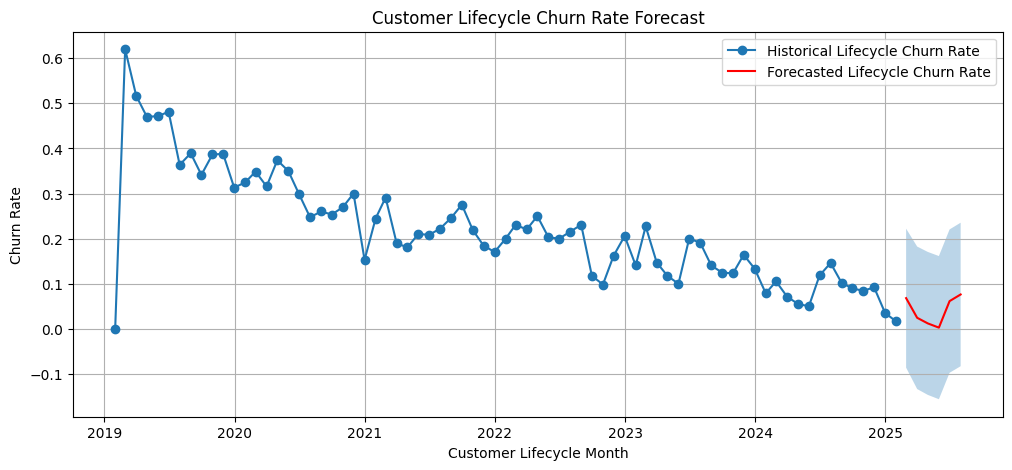

In [35]:
#10. Forecast Visualization
plt.figure(figsize=(12,5))

plt.plot(ts_data.index, ts_data.values, label="Historical Lifecycle Churn Rate", marker='o')
plt.plot(forecast_index, forecast_values.values, label="Forecasted Lifecycle Churn Rate", color='red')

plt.fill_between(
    forecast_index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("Customer Lifecycle Churn Rate Forecast")
plt.xlabel("Customer Lifecycle Month")
plt.ylabel("Churn Rate")
plt.grid(True)
plt.show()